# **ІАД**

## **Лаб 4. Кацуба Тимофій КН-42**

# 1. завантаження та первинний огляд даних

In [2]:
import pandas as pd
import numpy as np

file_path = '/Users/timofijmazestik/Downloads/train.csv'
df = pd.read_csv(file_path)

print("перші рядки датасету:")
display(df.head())

print("\nтехнічна інформація:")
df.info()

# рахуємо кількість порожніх клітинок
print("\nкількість пропущених значень у кожній колонці:")
print(df.isnull().sum())

перші рядки датасету:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



технічна інформація:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

кількість пропущених значень у кожній колонці:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0

# 2.Обробка даних

In [3]:

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=cols_to_drop)

df['Age'] = df['Age'].fillna(df['Age'].median())

most_common_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_port)

# оцифровуємо стать: чоловік - 0, жінка - 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# створює окремі колонки для кожного порту
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("перші рядки після очищення:")
display(df.head())

print("\nкількість пропущених значень тепер:")
print(df.isnull().sum())

перші рядки після очищення:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True



кількість пропущених значень тепер:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


# 3. Поділ даних та навчання моделі

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns=['Survived'])
y = df['Survived']

# ділимо вибірку: 80% на навчання, 20% на тест. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# перевіряємо чи правильно розбилися дані
print("розмір навчальної вибірки (X_train):", X_train.shape)
print("розмір тестової вибірки (X_test):", X_test.shape)

# створюємо порожню модель дерева рішень
clf = DecisionTreeClassifier(random_state=42)

# запускаємо процес навчання на тренувальних даних
clf.fit(X_train, y_train)

#зробити прогноз для тестових даних
y_pred = clf.predict(X_test)

print("\nструктура моделі:")
print("максимальна глибина дерева:", clf.get_depth())
print("кількість кінцевих вузлів (листків):", clf.get_n_leaves())

розмір навчальної вибірки (X_train): (712, 8)
розмір тестової вибірки (X_test): (179, 8)

структура моделі:
максимальна глибина дерева: 21
кількість кінцевих вузлів (листків): 179


# 4. Оцінювання якості моделі та аналіз метрик

реальна кількість загиблих (0) та тих хто вижив (1) у тестовій вибірці:
Survived
0    105
1     74
Name: count, dtype: int64


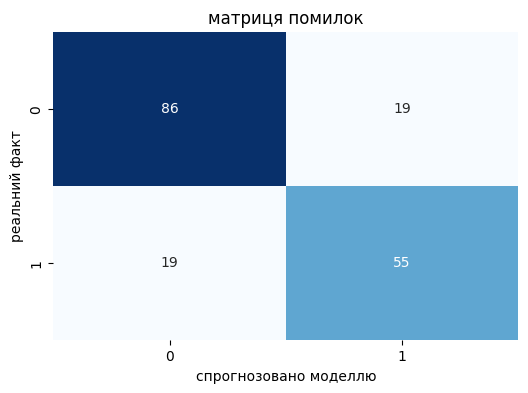


детальний звіт класифікації:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# дивимося на реальний баланс класів у тестовій вибірці
print("реальна кількість загиблих (0) та тих хто вижив (1) у тестовій вибірці:")
print(y_test.value_counts())

# генеруємо матрицю помилок
conf_matrix = confusion_matrix(y_test, y_pred)

# малюємо матрицю 
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('матриця помилок')
plt.xlabel('спрогнозовано моделлю')
plt.ylabel('реальний факт')
plt.show()

print("\nдетальний звіт класифікації:")
print(classification_report(y_test, y_pred))

# 5. Інтерпретація моделі

вагомість факторів у прийнятті рішення:


,feature,importance
1,Sex,0.310280
5,Fare,0.263543
2,Age,0.206181
0,Pclass,0.111937
3,SibSp,0.059694
4,Parch,0.027496
7,Embarked_S,0.016200
6,Embarked_Q,0.004669


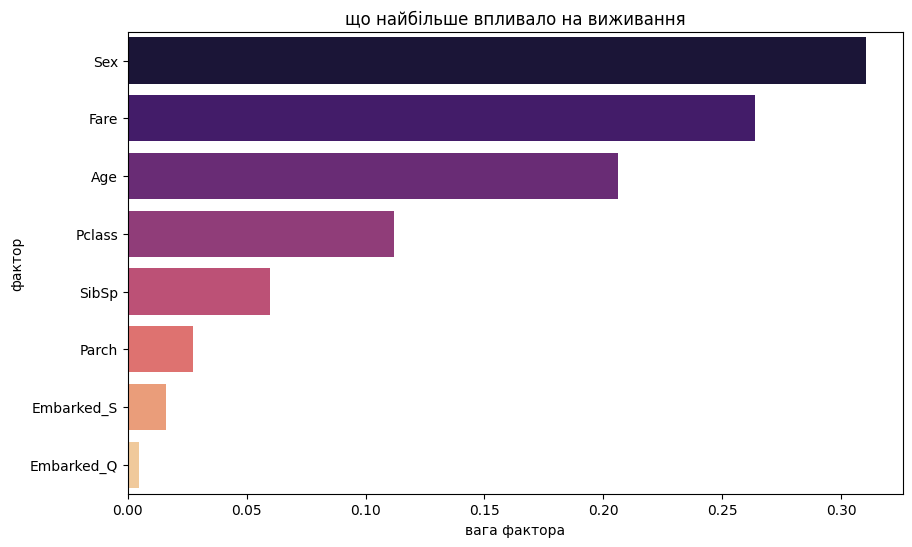

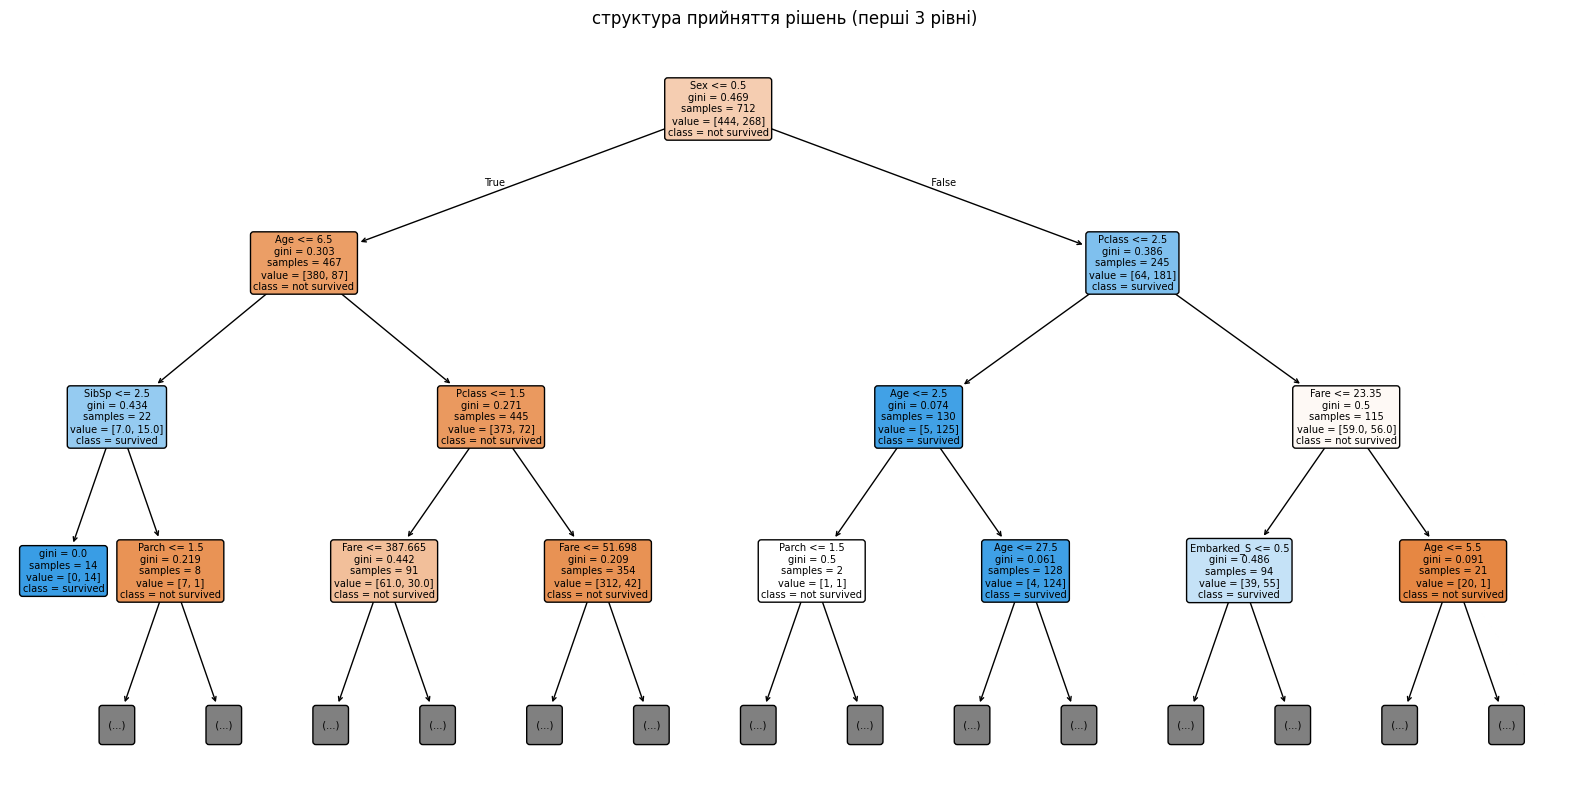

In [7]:
from sklearn.tree import plot_tree

# витягуємо важливість ознак з нашої навченої моделі clf
importances = clf.feature_importances_
features = X.columns

# створюємо табличку і сортуємо від найважливішого до найменш важливого
feat_imp = pd.DataFrame({'feature': features, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

print("вагомість факторів у прийнятті рішення:")
display(feat_imp)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp, hue='feature', palette='magma', legend=False)
plt.title('що найбільше впливало на виживання')
plt.xlabel('вага фактора')
plt.ylabel('фактор')
plt.show()

# обмежуємо до 3 рівнів щоб текст можна було прочитати
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=features, 
          class_names=['not survived', 'survived'], 
          filled=True, 
          rounded=True, 
          max_depth=3)
plt.title('структура прийняття рішень (перші 3 рівні)')
plt.show()